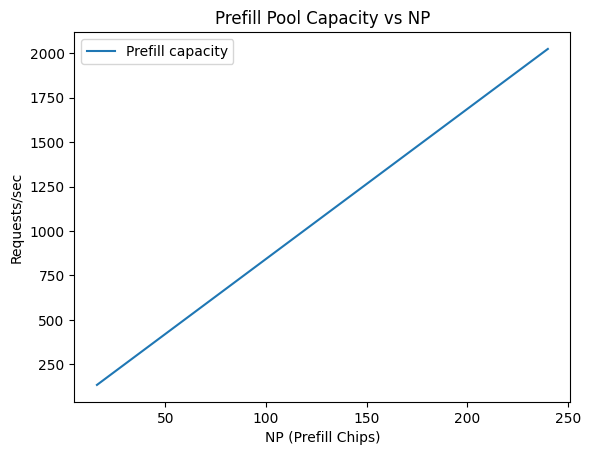

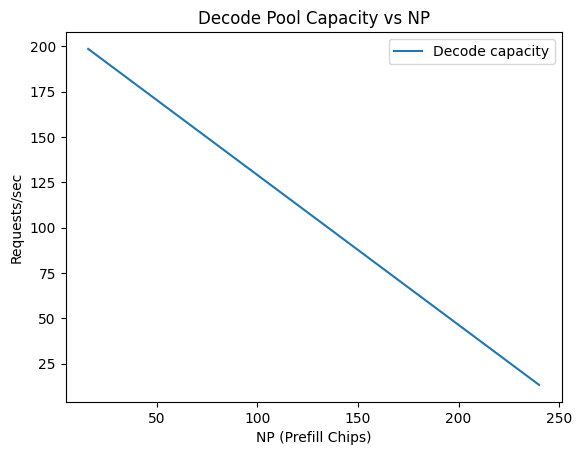

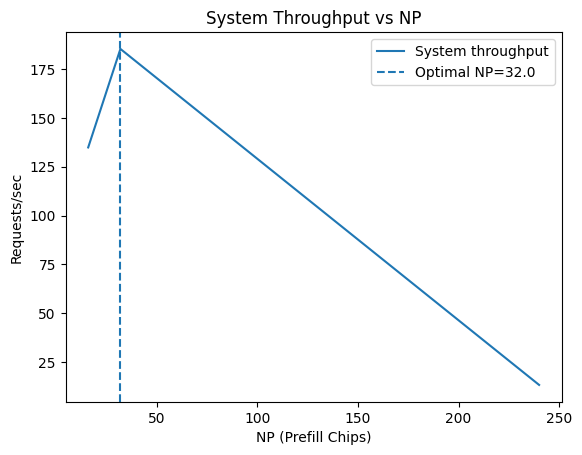

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/jasondhand/ECE511/MP4/ece511_final_project/results/pd_sweep/pd_sweep_results.csv")

alloc = df[df["row_type"] == "allocation_sweep"]

best_np = alloc[alloc["is_optimal"] == True]["NP"].values[0]

# -------------------------
# 1. Prefill capacity
# -------------------------
plt.figure()
plt.plot(alloc["NP"], alloc["prefill_pool_capacity_rps"], label="Prefill capacity")
# plt.axvline(best_np, linestyle="--", label=f"Optimal NP={best_np}")
plt.xlabel("NP (Prefill Chips)")
plt.ylabel("Requests/sec")
plt.title("Prefill Pool Capacity vs NP")
plt.legend()
plt.show()

# -------------------------
# 2. Decode capacity
# -------------------------
plt.figure()
plt.plot(alloc["NP"], alloc["decode_pool_capacity_rps"], label="Decode capacity")
# plt.axvline(best_np, linestyle="--", label=f"Optimal NP={best_np}")
plt.xlabel("NP (Prefill Chips)")
plt.ylabel("Requests/sec")
plt.title("Decode Pool Capacity vs NP")
plt.legend()
plt.show()

# -------------------------
# 3. System throughput
# -------------------------
plt.figure()
plt.plot(alloc["NP"], alloc["system_throughput_rps"], label="System throughput")
plt.axvline(best_np, linestyle="--", label=f"Optimal NP={best_np}")
plt.xlabel("NP (Prefill Chips)")
plt.ylabel("Requests/sec")
plt.title("System Throughput vs NP")
plt.legend()
plt.show()

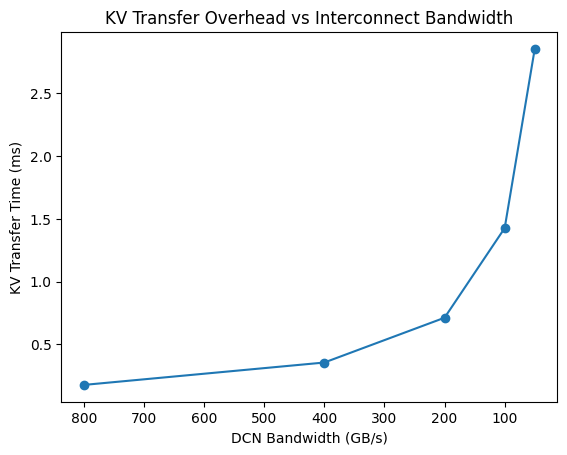

Prefill compute time (ms): 474.4532

Bandwidth 200 GB/s:
  tKV = 0.7130 ms
  Fraction of prefill time = 0.150%

Bandwidth 50 GB/s:
  tKV = 2.8521 ms
  Fraction of prefill time = 0.601%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/jasondhand/ECE511/MP4/ece511_final_project/results/pd_sweep/pd_sweep_results.csv")

# Only KV sweep rows
kv = df[df["row_type"] == "kv_bw_sensitivity"]

# Extract columns
bw = kv["dcn_bw_GBps"]
t_kv = kv["kv_transfer_time_ms"]

# ---- Plot KV transfer time vs bandwidth ----
plt.figure()
plt.plot(bw, t_kv, marker="o")
plt.xlabel("DCN Bandwidth (GB/s)")
plt.ylabel("KV Transfer Time (ms)")
plt.title("KV Transfer Overhead vs Interconnect Bandwidth")
plt.gca().invert_xaxis()  # optional: shows high bandwidth → low latency trend
plt.show()

# ---- Compare against prefill compute time ----
prefill_time = df[df["row_type"] == "allocation_sweep"]["TTFT_prefill_only_ms"].iloc[0]

print("Prefill compute time (ms):", prefill_time)

# ---- Fractions at required bandwidths ----
for target_bw in [200, 50]:
    row = kv[kv["dcn_bw_GBps"] == target_bw].iloc[0]
    tkv = row["kv_transfer_time_ms"]

    frac = tkv / prefill_time

    print(f"\nBandwidth {target_bw} GB/s:")
    print(f"  tKV = {tkv:.4f} ms")
    print(f"  Fraction of prefill time = {frac*100:.3f}%")